[2026-07-16 01:15:09] [info     ] 计算因子，测试区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-16 01:15:10] [info     ] 开始构建训练集                        train_end='2023-12-31 23:59:59' train_start='2019-01-01 00:00:00'
[2026-07-16 01:15:10] [info     ] build_features 开始              end='2023-12-31 23:59:59' start='2019-01-01 00:00:00'
[2026-07-16 01:15:12] [info     ] 财务原始字段查询完成                     elapsed=2.74 rows=4993289
[2026-07-16 01:16:49] [info     ] 量价原始字段查询完成                     elapsed=96.8 rows=2389640
[2026-07-16 01:16:50] [info     ] 标签计算完成                         elapsed=0.59
[2026-07-16 01:16:54] [info     ] BARRA暴露合并完成                    elapsed=2.42 exp_cols=46
[2026-07-16 01:16:57] [info     ] 日行情合并完成                        elapsed=2.88 new_cols=5
[2026-07-16 01:17:08] [info     ] 缺失值处理完成                        elapsed=11.15
[2026-07-16 01:17:09] [info     ] build_features 结束              rows=2389640 total_elapsed=119.36
[2026-07-16 01:17:11] [info     ] 开始训练模型       

时段,IC
2024-01-15~2024-02-08,0.0116
2024-09-24~2024-10-08,0.0383

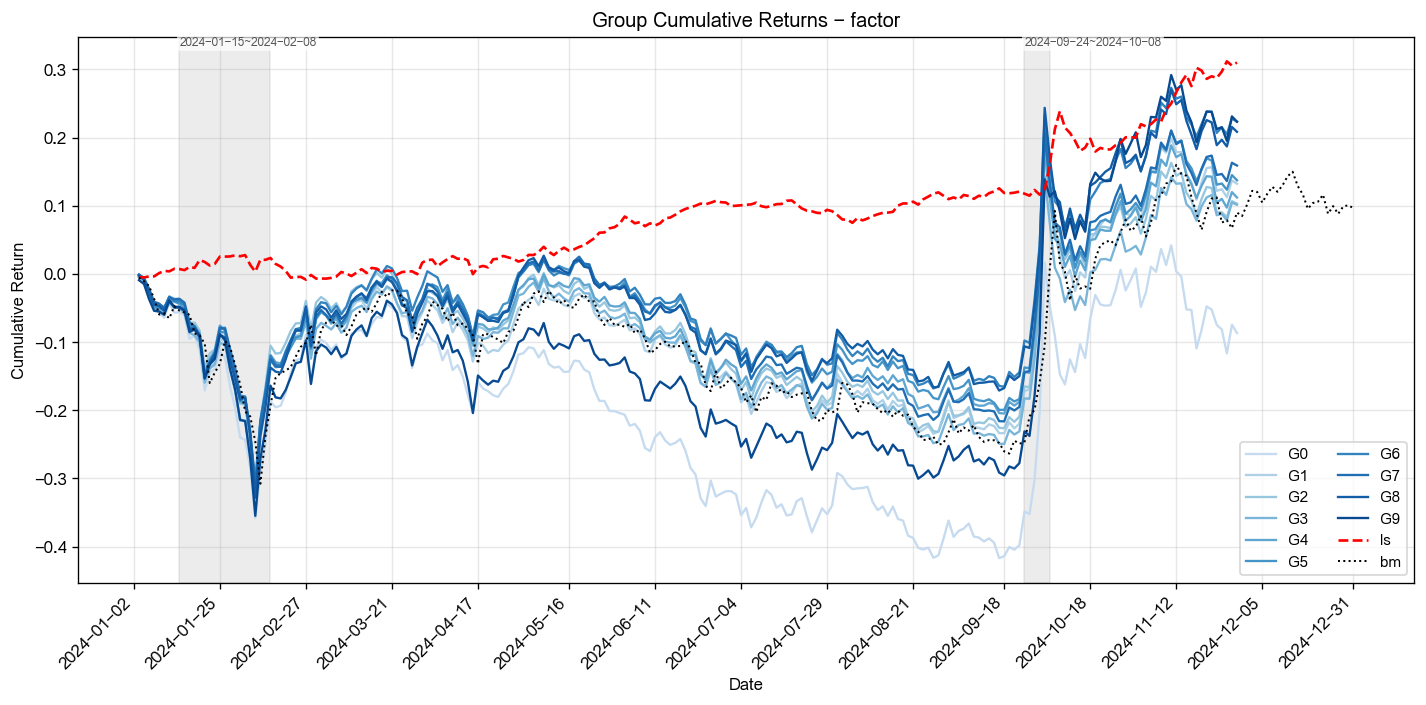
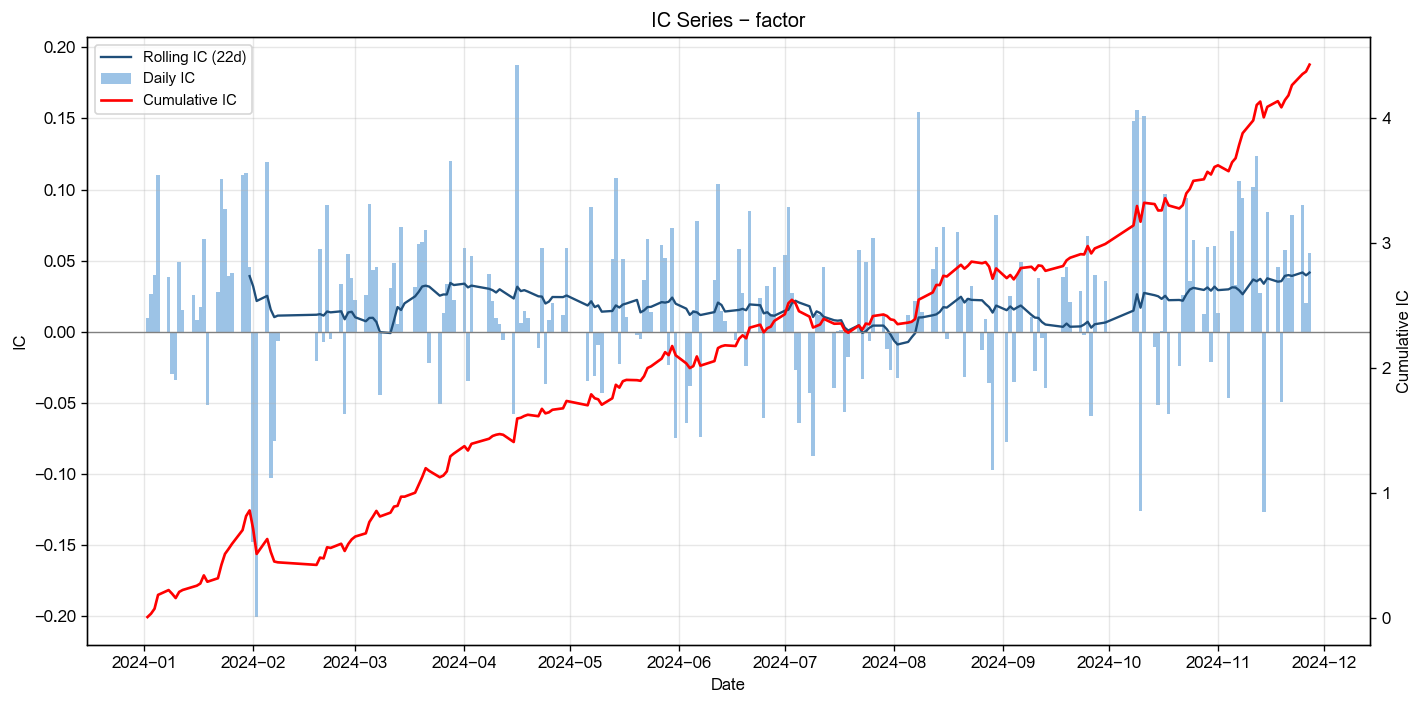
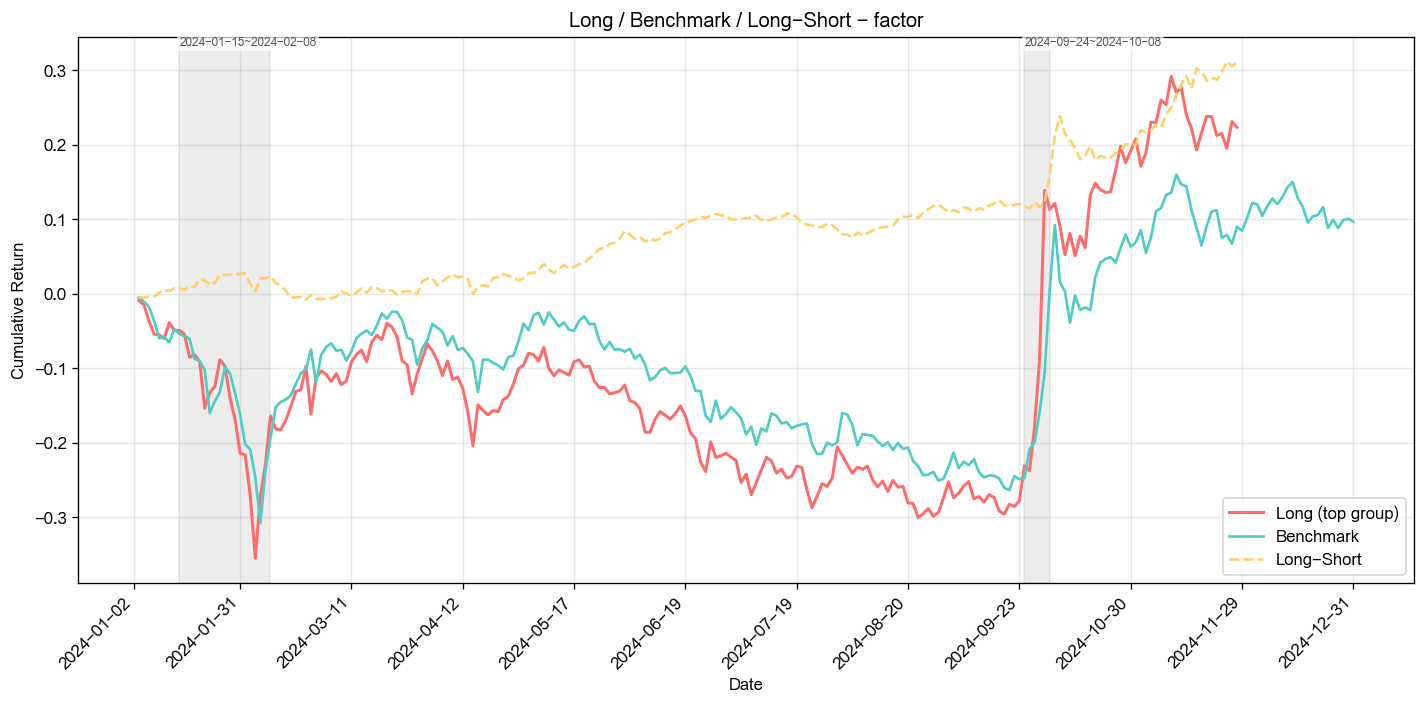
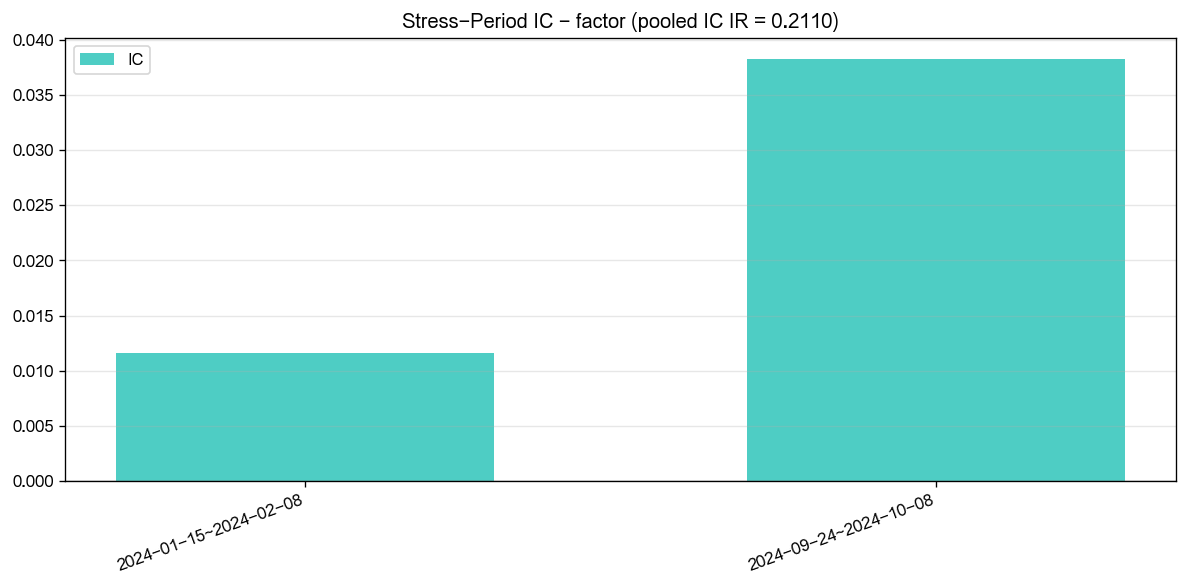
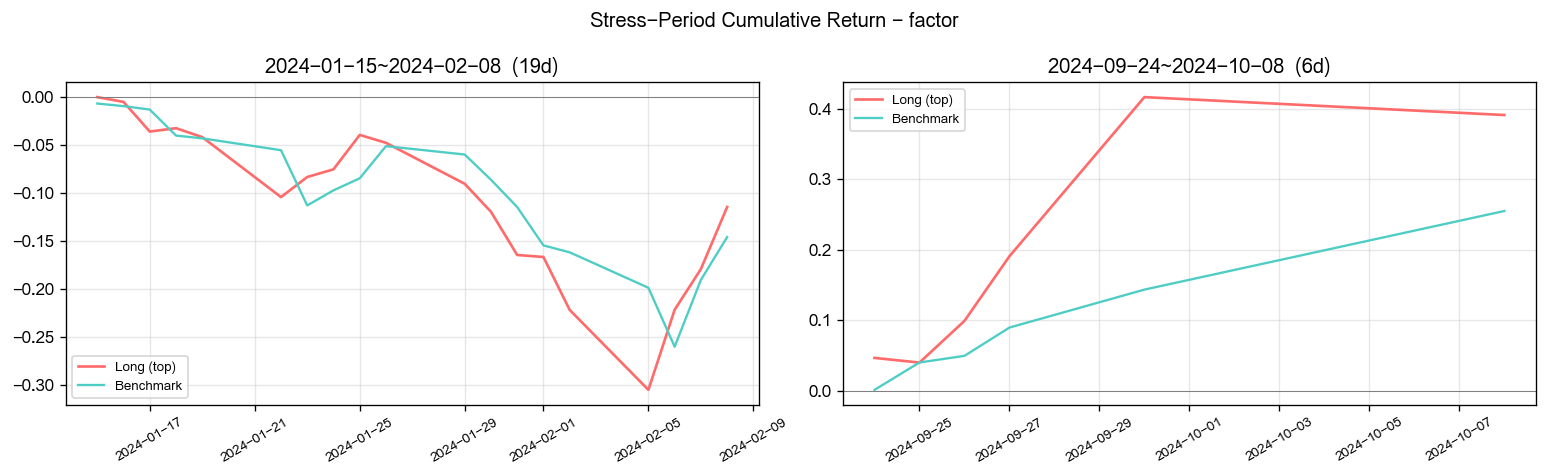

[2026-07-16 01:40:20] [info     ] ========== 因子池回归 ==========
[2026-07-16 01:40:20] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-07-16 01:40:20] [info     ] 获取收益率数据, 耗时: 0.7383 秒
[2026-07-16 01:40:21] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.8107 秒
[2026-07-16 01:40:21] [info     ] 统计 回归结果, 耗时: 0.1036 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,factor,2.2379,0.0285,0.0127,1.0000
2,rsi_12,1.8749,0.0454,0.0242,1.0000
3,cci_14,1.5925,0.0348,0.0218,1.0000
4,netflow_amount_rate_main,1.5136,0.0102,0.0068,1.0000
5,gross_profit_rate_ttm,1.5029,0.0067,0.0045,1.0000
6,netflow_amount_main,1.4828,0.0237,0.0160,1.0000
7,amount,1.4447,0.0137,0.0095,1.0000
8,net_profit_rate_ttm,1.4271,0.0041,0.0029,0.8000
9,pb,1.4205,0.0097,0.0069,0.9000
10,ps_ttm,1.3440,0.0041,0.0031,0.8000

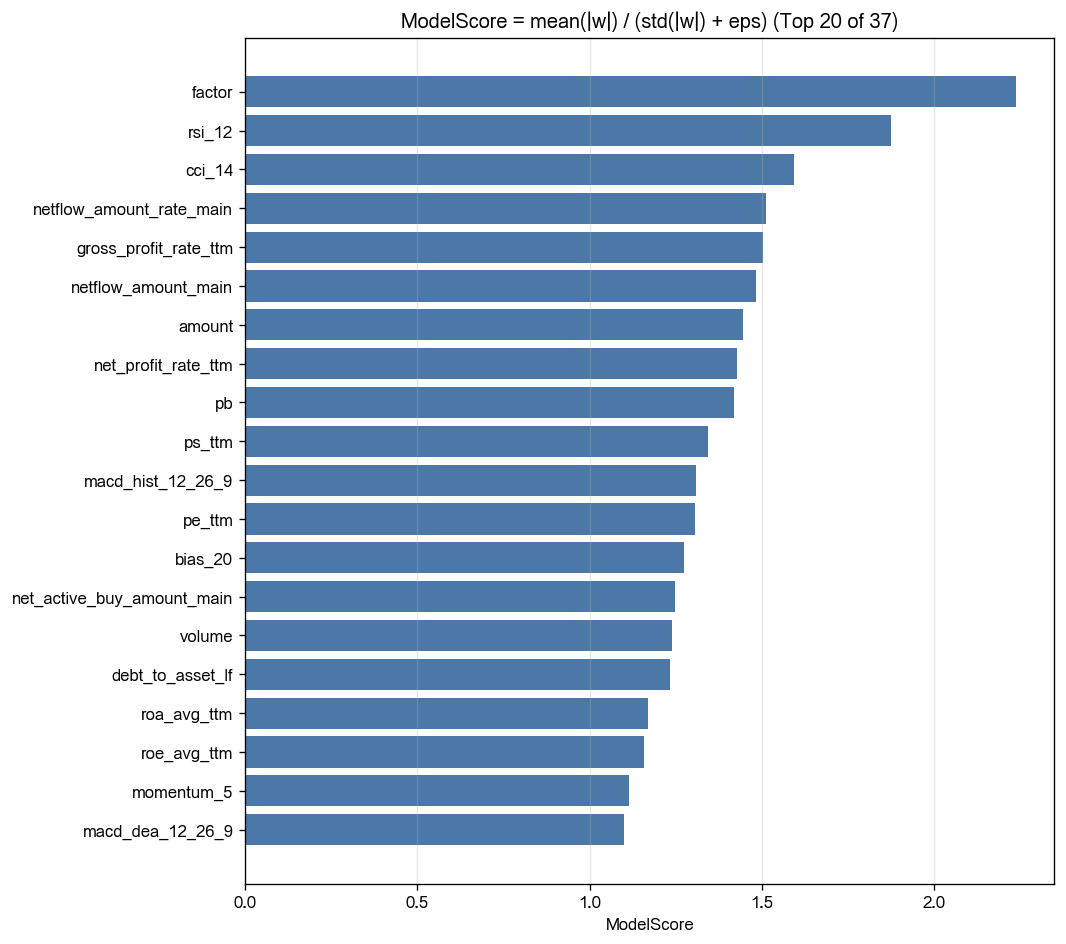
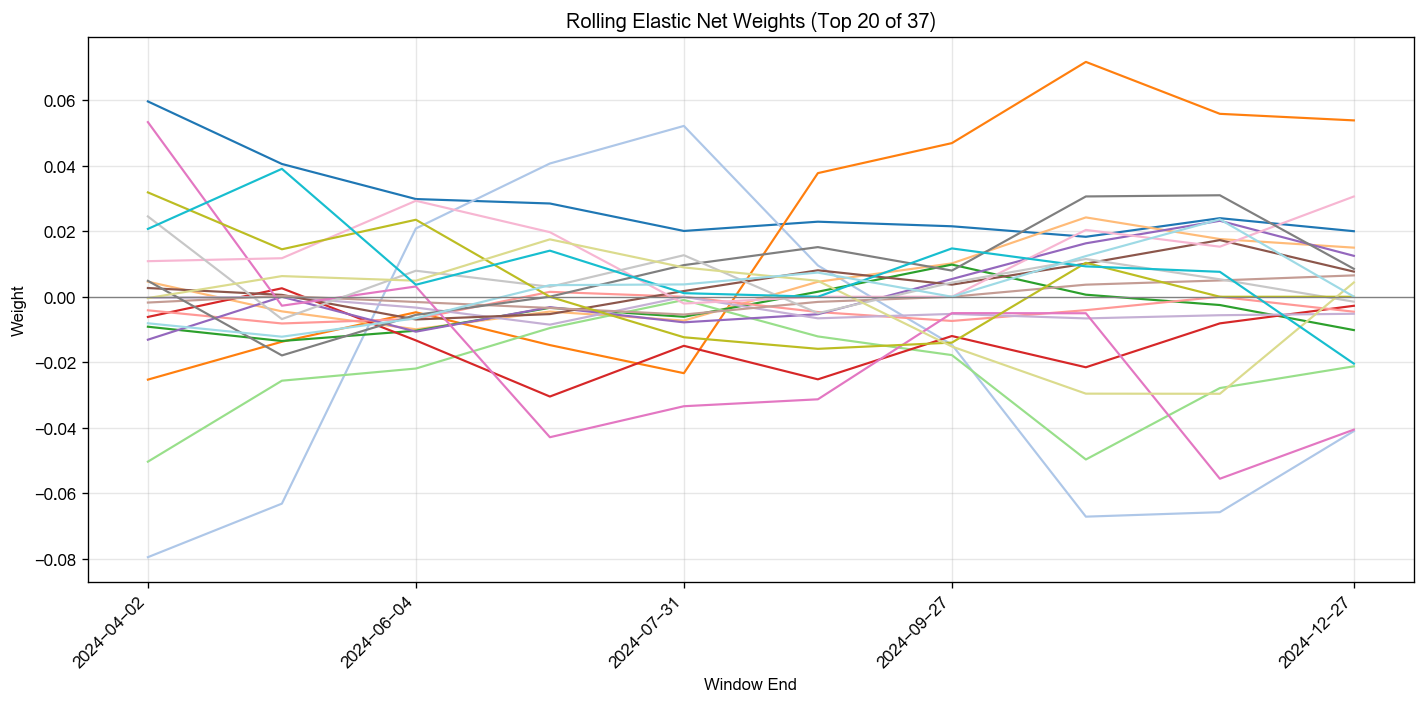
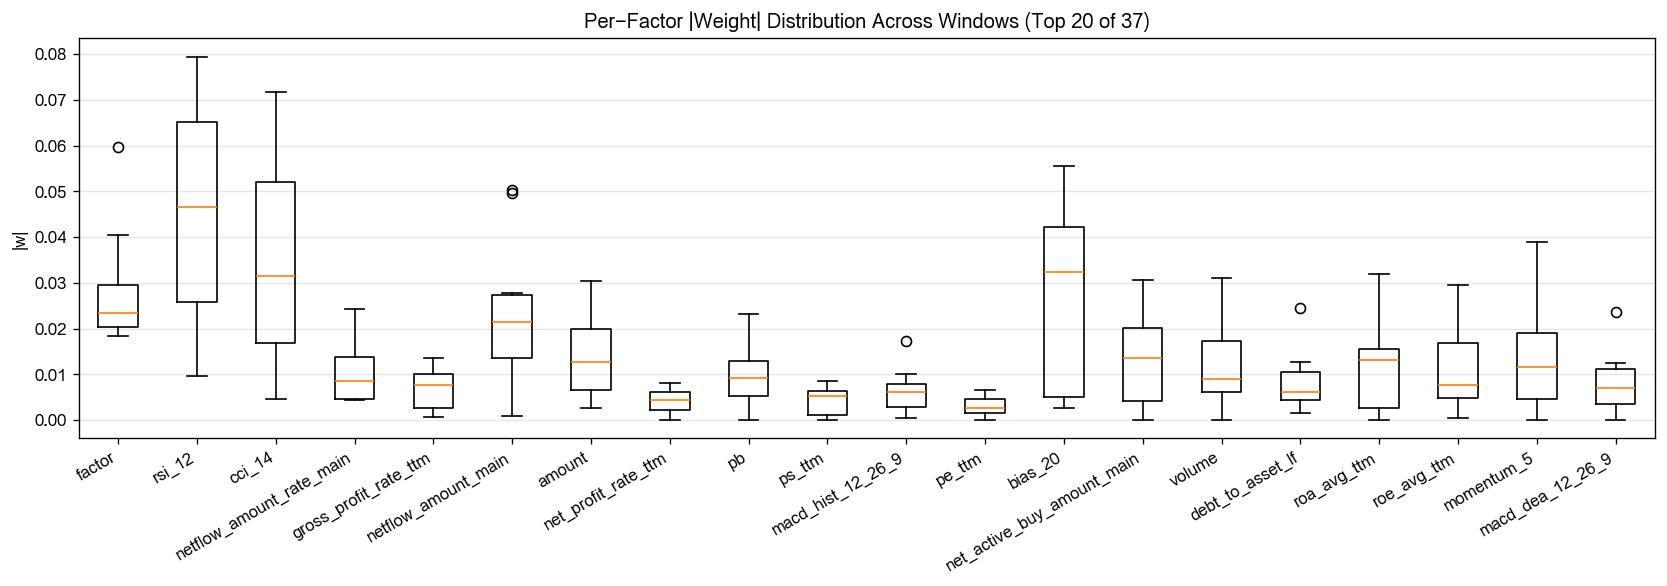
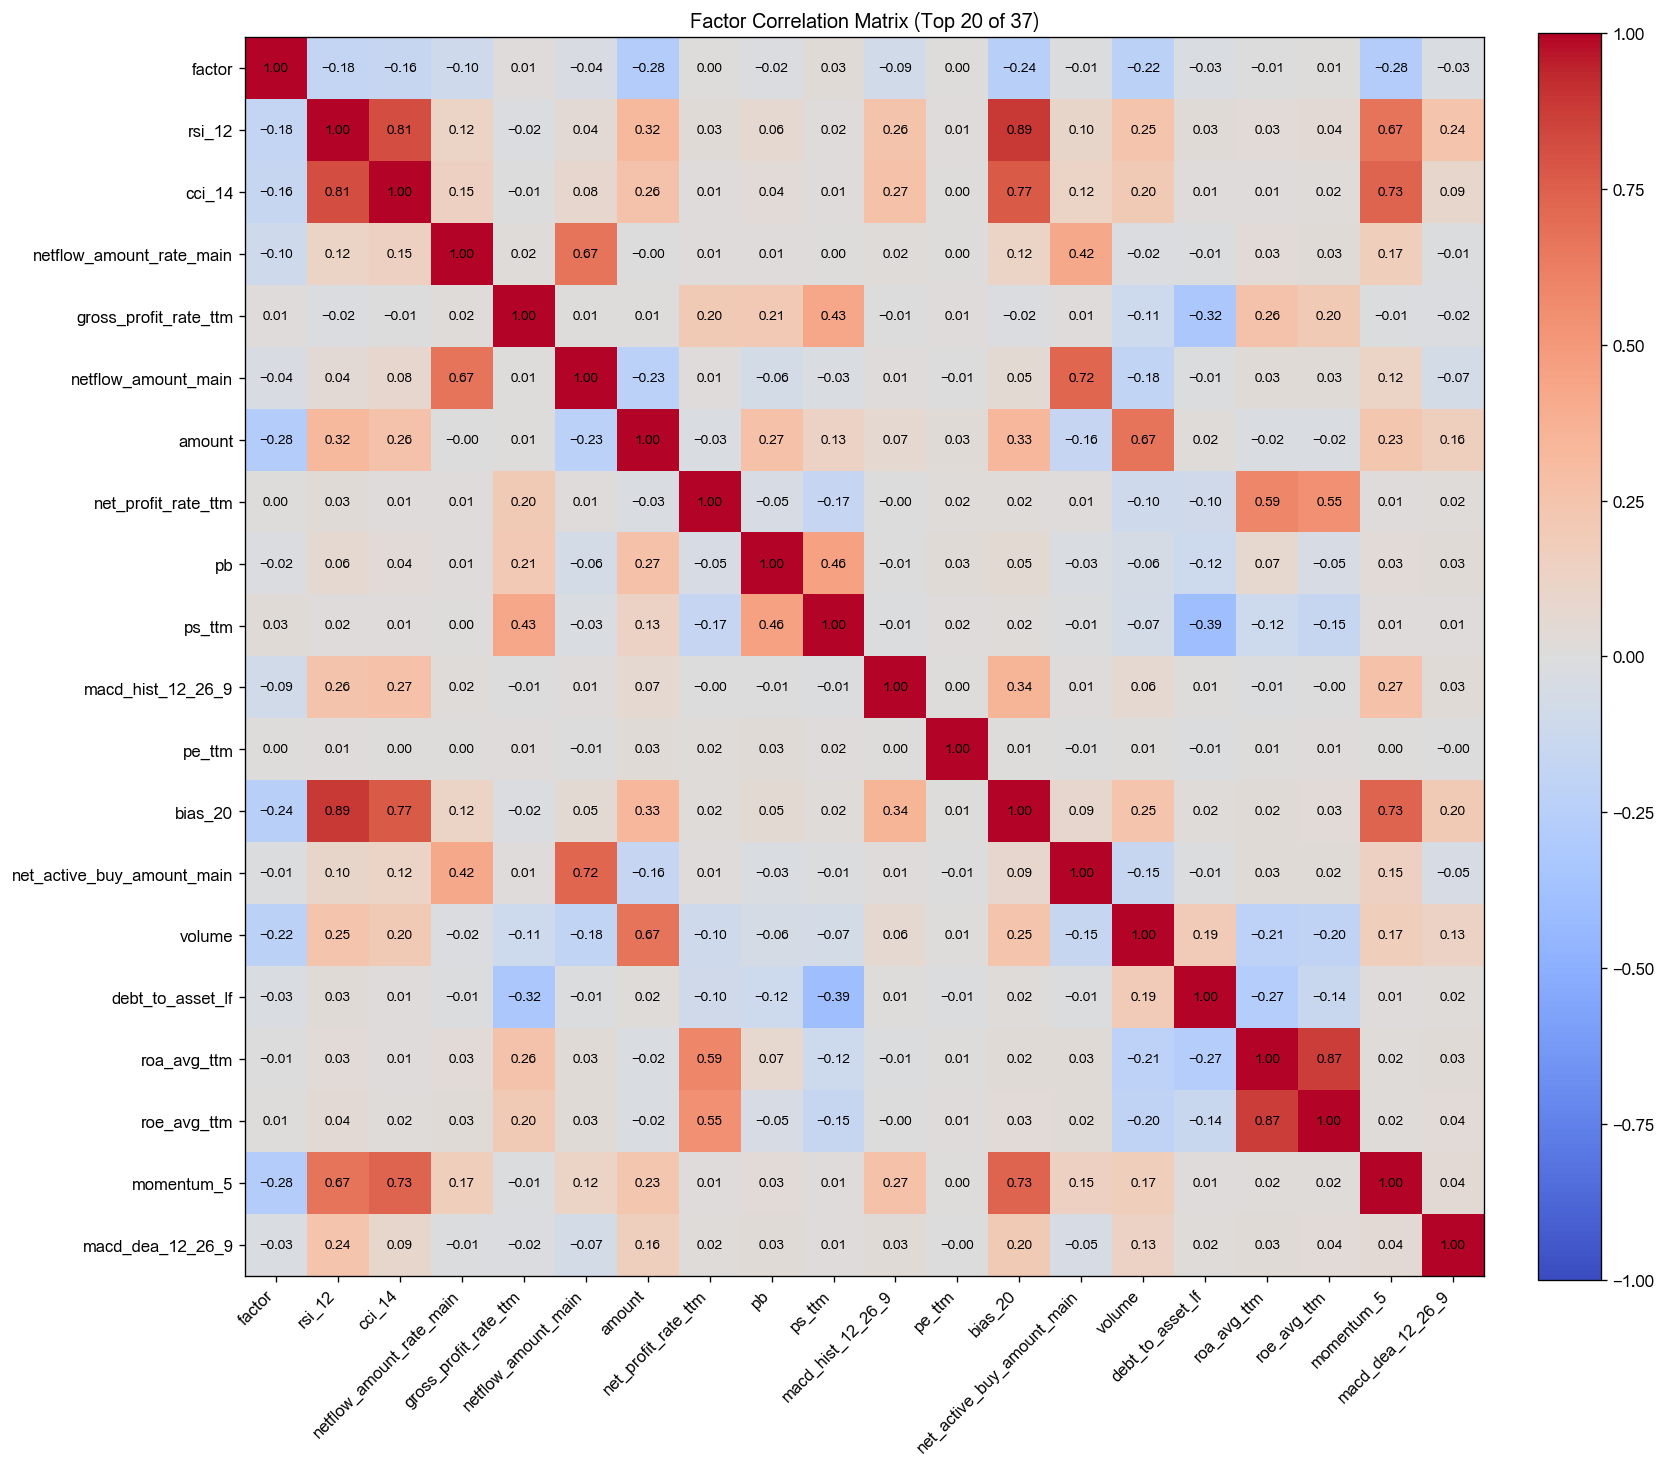

[2026-07-16 01:40:24] [warning  ] 返回的Outputs实例(size=35279087) 大于 64K, 将不会被缓存
[2026-07-16 01:40:24] [info     ] bigalpha_eval.v4 运行完成 [30.166s].


In [1]:
def main(datasources, start_date, end_date):
    # 🟠----------------------------------------------------------------------
    # 🟠【函数说明】这是整个程序的入口，平台会自动调用这个函数
    # 🟠  - datasources: 平台传进来的字典，告诉你去哪张表取数据
    # 🟠  - start_date:  平台要你做预测的起止日期（测试集，不是训练集！）
    # 🟠  - end_date:    平台要你做预测的结束日期
    # 🟠  返回值：一个DataFrame，必须有 date / instrument / factor 三列
    # 🟠----------------------------------------------------------------------
    import time        # 🟠 用来计时，看代码跑了多久
    import numpy as np # 🟠 数学计算库，处理数组、无穷值等
    import pandas as pd# 🟠 表格数据处理库，DataFrame就是它提供的
    import dai         # 🟠 BigQuant自研的数据引擎（只能在平台AIStudio用）
    import xgboost as xgb  # 🟠 XGBoost机器学习库，用来训练预测模型
    import structlog   # 🟠 日志库，打印运行信息
    from sklearn.model_selection import train_test_split  # 🟠 划分训练集/验证集

    logger = structlog.get_logger()  # 🟠 创建一个日志记录器，后面用它输出运行状态

    # 🟠----------------------------------------------------------------------
    # 🟠【训练区间】写死在代码里，永远不变
    # 🟠  模型只在这段时间的数据上学习规律，不能用到平台传的测试日期
    # 🟠----------------------------------------------------------------------
    TRAIN_START = '2019-01-01 00:00:00'  # 🟠 训练数据起始日期
    TRAIN_END   = '2023-12-31 23:59:59'  # 🟠 训练数据结束日期

    # ╔══════════════════════════════════════════════════════════════════════╗
    # ║  🟠【特征列定义】——这里必须改！决定了模型用哪些数据来学习规律       ║
    # ║                                                                    ║
    # ║  特征列是整个代码的"总开关"：                                       ║
    # ║   1. 定义了 build_features() 要从数据库取哪些字段                  ║
    # ║   2. 定义了 model.fit() 训练时用哪些列作为输入X                    ║
    # ║   3. 定义了 model.predict() 预测时用哪些列                          ║
    # ║                                                                    ║
    # ║  ⚠️ 改这里只是"声明名字"，还需要同步改SQL查询才能真正拿到数据！    ║
    # ║  增加新特征时三步走：                                               ║
    # ║   ① 在这里定义新列名                                               ║
    # ║   ② 在 build_features() 的SQL里查询/计算出新列                     ║
    # ║   ③ 如果新列需要额外聚合（如日内波动率），在SQL里算好               ║
    # ╚══════════════════════════════════════════════════════════════════════╝
    price_cols = ['open', 'high', 'low', 'close', 'volume', 'amount',
                  'intraday_vol', 'intraday_return', 'close_position', 'buy_pressure',
                  'ret_5d', 'trade_count', 'spread', 'depth_imbalance', 'open_gap',
                  'mid_price_premium', 'turnover_intensity', 'order_size_imbalance',
                  'return_efficiency', 'panic_score']
    # 🟠 前6个=日线量价  intraday_vol=日内振幅  intraday_return=日内涨跌幅
    # 🟠 close_position=收盘位置  buy_pressure=买方委托占比  ret_5d=5日动量
    # 🟠 trade_count=成交笔数  spread=买卖价差  depth_imbalance=前5档深度失衡
    # 🟠 open_gap=跳空幅度  mid_price_premium=均价偏离度
    # 🟠 turnover_intensity=每笔成交量  order_size_imbalance=大单方向  return_efficiency=收益效率

    fin_cols = ['operating_revenue', 'net_profit_to_parent_shareholders',
                'total_assets', 'total_equity_to_parent_shareholders']
    # 🟠 前4个=原始财务字段（数据库里真实存在的列）

    feature_cols = price_cols + fin_cols + ['roe', 'asset_liability_ratio']
    # 🟠 基准：25个特征  build_features 运行后会动态追加 exposure/bar1d 列


    # ╔══════════════════════════════════════════════════════════════════════╗
    # ║  🟠 build_features()：核心函数——从数据库构建特征表 + 计算标签           ║
    # ║  🟠 输入：数据表名 + 起止日期                                          ║
    # ║  🟠 输出：包含25+特征 + 1个label 的DataFrame（运行时动态追加exposure列）║
    # ╚══════════════════════════════════════════════════════════════════════╝
    def build_features(financial_table, bar1m_table, sd, ed):
        t0 = time.time()  # 🟠 记录开始时间
        logger.info("build_features 开始", start=str(sd), end=str(ed))

        # 🟠----------------------------------------
        # 🟠【步骤A】查财务数据
        # 🟠  - category='lf': 取最新一期财报（Latest Filing）
        # 🟠  - shift=0: 不偏移，用公告日的数据
        # 🟠  - 往前多取365天，保证最早的日期也能用 ffill 填上值
        # 🟠  ⚠️ fin_select 直接用最上面定义的 fin_cols 拼出SQL：
        # 🟠     如果 fin_cols = ['a', 'b'] → SELECT date, instrument, a, b FROM ...
        # 🟠     所以你加了新特征列只需要在 fin_cols 里加名字，这里自动跟上！
        # 🟠----------------------------------------
        fin_start = pd.to_datetime(sd) - pd.Timedelta(days=365)  # 🟠 往前推365天作为起始
        fin_select = ', '.join(fin_cols)  # 🟠 自动把 ['a','b','c'] 拼成 "a, b, c" 塞进SQL
        fin_sql = f"""
        SELECT date, instrument, {fin_select}
        FROM {financial_table}
        WHERE category='lf' AND shift=0
        """
        fin = dai.query(fin_sql, filters={'date': [fin_start, ed]}).df()

        # 🟠 fill_natural_dates()：把"按公告日存储"的财务数据 → 变成"每一天都有值"
        # 🟠 原理：每个股票用 ffill（前向填充），把最新公告值复制到后续每一天
        # 🟠 比如：3月15日公告Q1财报 → 3月15日之后每一天都用Q1数据
        def fill_natural_dates(df: pd.DataFrame, sd: str, ed: str) -> pd.DataFrame:
            natural_dates = pd.date_range(start=sd, end=ed)  # 🟠 生成从sd到ed的每一天
            df.set_index('date', inplace=True)  # 🟠 把日期设为行索引
            def reindex_and_fill(group_df):
                """对每只股票单独处理"""
                reindexed_df = group_df.reindex(natural_dates)  # 🟠 重新索引，缺失日期填NaN
                instrument_name = group_df.name
                filled_df = reindexed_df.ffill()  # 🟠 关键！前向填充：今天没公告就用昨天的值
                filled_df['instrument'] = instrument_name
                return filled_df
            df_filled = df.groupby('instrument', group_keys=False).apply(reindex_and_fill)
            df_filled = (
                df_filled.reset_index()           # 🟠 把索引(date)还原为普通列
                .rename(columns={'index': 'date'})# 🟠 索引列重命名为 'date'
                .dropna(subset=['instrument'])    # 🟠 删除instrument为空的行
            )
            return df_filled
        fin = fill_natural_dates(fin, fin_start, ed)
        fin['date'] = pd.to_datetime(fin['date'])
        logger.info("财务原始字段查询完成", rows=len(fin), elapsed=round(time.time() - t0, 2))


        # 🟠----------------------------------------
        # 🟠【步骤B】查1分钟K线数据 → 聚合成日线
        # 🟠  - date_trunc('day', date): 把分钟时间戳截断到"天"
        # 🟠  - ARG_MIN(open, date): 取日期最早的open → 当日开盘价
        # 🟠  - ARG_MAX(close, date): 取日期最晚的close → 当日收盘价
        # 🟠  - MAX(high) / MIN(low): 当日最高/最低价
        # 🟠  - SUM(volume/amount): 当日总成交量/成交额
        # 🟠  - 往前多取30天作为buffer（rolling计算需要足够历史数据）
        # 🟠----------------------------------------
        t1 = time.time()
        price_start = pd.to_datetime(sd) - pd.Timedelta(days=30)  # 多取30天用于rolling计算
        price_sql = f"""
        SELECT
            date_trunc('day', date)::DATE           AS trading_day,
            instrument,
            ARG_MIN(open, date)                     AS open,
            MAX(high)                               AS high,
            MIN(low)                                AS low,
            ARG_MAX(close, date)                    AS close,
            SUM(volume)                             AS volume,
            SUM(amount)                             AS amount,
            (MAX(high) - MIN(low)) / (ARG_MIN(open, date) + 0.0001)    AS intraday_vol,
            ARG_MAX(close, date) / (ARG_MIN(open, date) + 0.0001) - 1  AS intraday_return,
            (ARG_MAX(close, date) - MIN(low)) / (MAX(high) - MIN(low) + 0.0001) AS close_position,
            SUM(bid_volume1 + bid_volume2 + bid_volume3 + bid_volume4 + bid_volume5) /
                (SUM(bid_volume1 + bid_volume2 + bid_volume3 + bid_volume4 + bid_volume5) +
                 SUM(ask_volume1 + ask_volume2 + ask_volume3 + ask_volume4 + ask_volume5) + 0.0001) AS buy_pressure,
            SUM(deal_number)                        AS trade_count,
            SUM(deal_number) / (SUM(volume) + 0.0001)                    AS turnover_intensity,
            (SUM(bid_volume1) / (SUM(bid_num_orders1) + 0.0001)) /
                (SUM(ask_volume1) / (SUM(ask_num_orders1) + 0.0001) + 0.0001) AS order_size_imbalance,
            AVG((ask_price1 - bid_price1) / (close + 0.0001))          AS spread,
            (SUM(bid_volume1) + SUM(bid_volume2) + SUM(bid_volume3) + SUM(bid_volume4) + SUM(bid_volume5)) /
                (SUM(bid_volume1) + SUM(bid_volume2) + SUM(bid_volume3) + SUM(bid_volume4) + SUM(bid_volume5) +
                 SUM(ask_volume1) + SUM(ask_volume2) + SUM(ask_volume3) + SUM(ask_volume4) + SUM(ask_volume5) + 0.0001) AS depth_imbalance,
            (ARG_MIN(open, date) - ARG_MIN(pre_close, date)) / (ARG_MIN(pre_close, date) + 0.0001) AS open_gap,
            (SUM(bid_price1 * bid_volume1 + bid_price2 * bid_volume2 + bid_price3 * bid_volume3 + bid_price4 * bid_volume4 + bid_price5 * bid_volume5) /
                (SUM(bid_volume1 + bid_volume2 + bid_volume3 + bid_volume4 + bid_volume5) + 0.0001) +
             SUM(ask_price1 * ask_volume1 + ask_price2 * ask_volume2 + ask_price3 * ask_volume3 + ask_price4 * ask_volume4 + ask_price5 * ask_volume5) /
                (SUM(ask_volume1 + ask_volume2 + ask_volume3 + ask_volume4 + ask_volume5) + 0.0001)) / 2 / (AVG(close) + 0.0001) - 1 AS mid_price_premium,
            -(ARG_MAX(close, date) - MIN(low)) / (MAX(high) - MIN(low) + 0.0001) * ((MAX(high) - MIN(low)) / (ARG_MIN(open, date) + 0.0001)) AS panic_score
        FROM {bar1m_table}
        GROUP BY trading_day, instrument
        ORDER BY trading_day, instrument
        """
        price = dai.query(price_sql, filters={'date': [price_start, ed]}).df().rename(columns={'trading_day': 'date'})
        price['date'] = pd.to_datetime(price['date'])
        price = price.sort_values(['instrument', 'date']).reset_index(drop=True)
        logger.info("量价原始字段查询完成", rows=len(price), elapsed=round(time.time() - t1, 2))

        # 🟠----------------------------------------
        # 🟠【步骤C】构造标签（label）——模型要学的东西
        # 🟠  label = 明天的收盘价 / 今天的收盘价 - 1
        # 🟠  也就是"未来1日的收益率"
        # 🟠  shift(-1): 把下一行的值挪到当前行来
        # 🟠----------------------------------------
        t2 = time.time()
        g = price.groupby('instrument', group_keys=False)['close']
        price['label'] = (g.shift(-1) + g.shift(-2)) / (2 * price['close']) - 1

        # 🟠 追加动量特征：5日收益率（回溯过去5天的涨跌）
        g_close = price.groupby('instrument', group_keys=False)['close']
        price['ret_5d'] = g_close.pct_change(5)
        logger.info("标签计算完成", elapsed=round(time.time() - t2, 2))

        # 🟠----------------------------------------
        # 🟠【步骤D】把量价数据和财务数据按 date + instrument 合并
        # 🟠  inner join: 只保留两边都有的行
        # 🟠----------------------------------------
        df = pd.merge(price, fin, how='inner', on=['date', 'instrument'])

        # 🟠 追加财务衍生特征：用原始字段做除法计算比率指标
        eps = 1e-8  # 防止除零
        df['roe'] = df['net_profit_to_parent_shareholders'] / (df['total_equity_to_parent_shareholders'] + eps)
        df['asset_liability_ratio'] = (df['total_assets'] - df['total_equity_to_parent_shareholders']) / (df['total_assets'] + eps)

        # 🟠 追加已有列交叉衍生特征
        df['return_efficiency'] = df['intraday_return'] / (df['intraday_vol'] + eps)

        # 🟠 读取 BARRA 风险暴露数据 + 合并
        t_exp = time.time()
        exposure = dai.query(
            "SELECT * FROM bigalpha_2026_exposure",
            filters={'date': [sd, ed]},
        ).df()
        exposure['date'] = pd.to_datetime(exposure['date'])
        exposure['instrument'] = exposure['instrument'].astype(str)
        # 只保留数值列（排除 date, instrument）
        exposure_value_cols = [c for c in exposure.columns if c not in ('date', 'instrument')]
        df = pd.merge(df, exposure, how='left', on=['date', 'instrument'])
        # 动态追加到 feature_cols
        for c in exposure_value_cols:
            if c not in feature_cols:
                feature_cols.append(c)
        logger.info("BARRA暴露合并完成", exp_cols=len(exposure_value_cols),
                    elapsed=round(time.time() - t_exp, 2))

        # 🟠 读取日频行情数据（bar1d） + 只合并新列
        t_1d = time.time()
        bar1d = dai.query(
            "SELECT * FROM bigalpha_2026_bar1d",
            filters={'date': [sd, ed]},
        ).df()
        bar1d['date'] = pd.to_datetime(bar1d['date'])
        bar1d['instrument'] = bar1d['instrument'].astype(str)
        # 排除 date、instrument 以及 df 中已存在的列（避免重复 OHLCV）
        bar1d_new_cols = [c for c in bar1d.columns
                          if c not in ('date', 'instrument') and c not in df.columns]
        if bar1d_new_cols:
            df = pd.merge(df, bar1d[['date', 'instrument'] + bar1d_new_cols],
                         how='left', on=['date', 'instrument'])
            for c in bar1d_new_cols:
                if c not in feature_cols:
                    feature_cols.append(c)
        logger.info("日行情合并完成", new_cols=len(bar1d_new_cols),
                    elapsed=round(time.time() - t_1d, 2))

        # 🟠----------------------------------------
        # 🟠【步骤E】清洗数据
        # 🟠  1. 把 object 列转成数值（DAI的SUM可能返回Python Decimal对象，XGBoost不认）
        # 🟠  2. 把无穷大替换成 NaN
        # 🟠----------------------------------------
        t3 = time.time()
        for col in feature_cols:
            df[col] = pd.to_numeric(df[col], errors='coerce')  # 🟠 强制转数值，转不了的变NaN
            df[col] = df[col].replace([np.inf, -np.inf], np.nan)  # 🟠 无穷大→NaN
        logger.info("缺失值处理完成", elapsed=round(time.time() - t3, 2))

        # 🟠----------------------------------------
        # 🟠【步骤F】只保留目标区间内的数据
        # 🟠  前面多取的数据只是为了计算用的buffer，不输出
        # 🟠----------------------------------------
        df = df[(df['date'] >= pd.to_datetime(sd)) & (df['date'] <= pd.to_datetime(ed))]
        logger.info("build_features 结束", rows=len(df), total_elapsed=round(time.time() - t0, 2))
        return df.reset_index(drop=True)


    # ╔══════════════════════════════════════════════════════════════════════╗
    # ║  🟠【主流程第1步】用写死的训练区间构建训练数据，然后训练XGBoost模型 ║
    # ╚══════════════════════════════════════════════════════════════════════╝
    logger.info("开始构建训练集", train_start=TRAIN_START, train_end=TRAIN_END)
    # 🟠 注意：这里直接写死表名 'bigalpha_2026_financial' 和 'bigalpha_2026_stock_bar1m'
    # 🟠 训练时不需要用平台传的 datasources，因为训练区间的数据源是固定的
    train_df = build_features('bigalpha_2026_financial', 'bigalpha_2026_stock_bar1m', TRAIN_START, TRAIN_END)
    train_df['label'] = train_df['label'].replace([np.inf, -np.inf], np.nan)
    train_df = train_df.dropna(subset=['label'])

    # 🟠 划分训练集和验证集（时序数据不能打乱顺序，按80/20切分）
    train_part, val_part = train_test_split(train_df, test_size=0.2, shuffle=False)

    t_fit = time.time()
    logger.info("开始训练模型", train_samples=len(train_part), val_samples=len(val_part))
    model = xgb.XGBRegressor(
        n_estimators=500,       # 🟠 树的数量上限（early_stopping会提前停，用不完不浪费）
        max_depth=4,            # 🟠 每棵树的最大深度（4层，比模板略深）
        learning_rate=0.05,     # 🟠 学习率（步长），配合150棵树逐步逼近
        subsample=0.8,          # 🟠 每棵树随机用80%的样本训练（防止过拟合）
        colsample_bytree=0.8,   # 🟠 每棵树随机用80%的特征（防止过拟合）
        min_child_weight=10,    # 🟠 叶子节点最少样本权重（越大越保守）
        reg_lambda=1.0,         # 🟠 L2正则化系数（惩罚大权重，防止过拟合）
        tree_method='hist',     # 🟠 直方图算法：训练更快，内存更省
        n_jobs=-1,              # 🟠 用所有CPU核心并行训练
        random_state=42,        # 🟠 随机种子（固定后每次训练结果一样）
    )
    model.fit(
        train_part[feature_cols], train_part['label'],
        eval_set=[(val_part[feature_cols], val_part['label'])],
        early_stopping_rounds=50,  # 🟠 验证集50轮不提升就自动停止
        verbose=False,
    )
    # 🟠 有时early_stopping提前停了，实际建树数少于n_estimators
    logger.info("模型训练完成", elapsed=round(time.time() - t_fit, 2),
                best_iteration=model.best_iteration)


    # ╔══════════════════════════════════════════════════════════════════════╗
    # ║  🟠【主流程第2步】用平台传的测试区间 → 构建特征 → 模型预测 → 得因子 ║
    # ║  🟠 关键：这里用的是 datasources（平台注入的表名）和 start_date/end_date  ║
    # ║  🟠 这些是"未来的"数据，模型在训练时从未见过 → 真正的样本外预测         ║
    # ╚══════════════════════════════════════════════════════════════════════╝
    logger.info("开始构建测试集并预测")
    bar1m_table = datasources['bar1m']        # 🟠 从平台给的映射中取出分钟K线表名
    financial_table = datasources['financial']# 🟠 从平台给的映射中取出财务数据表名
    test_df = build_features(financial_table, bar1m_table, start_date, end_date)
    # 🟠 predict()：对测试集的每一行，模型输出一个预测值（这个值就是因子！）
    # 🟠 预测值越高 → 模型认为该股票未来的收益率越高
    test_df['factor'] = model.predict(test_df[feature_cols])


    # ╔══════════════════════════════════════════════════════════════════════╗
    # ║  🟠【主流程第3步】过滤中证1000成分股 + 整理输出格式                  ║
    # ║  🟠  只保留当天属于中证1000指数的股票，非成分股的因子不要              ║
    # ╚══════════════════════════════════════════════════════════════════════╝
    # 🟠 查询中证1000成分股池：某天哪些股票属于中证1000
    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={'date': [start_date, end_date]},
    ).df()
    stk_pool['instrument'] = stk_pool['instrument'].astype(str)  # 🟠 统一为字符串类型

    # 🟠 inner join：只保留同时出现在 test_df 和 stk_pool 中的行
    # 🟠 效果 -> 把非中证1000成分股剔除掉
    result = pd.merge(test_df[['date', 'instrument', 'factor']], stk_pool,
                    how='inner', on=['date', 'instrument'])
    result['factor'] = result['factor'].replace([np.inf, -np.inf], np.nan)  # 🟠 无穷→NaN
    result = result.dropna(subset=['factor']).reset_index(drop=True)[['date', 'instrument', 'factor']]
    # 🟠 最终输出：只保留三列，格式为 date | instrument | factor

    logger.info("因子构建完成", rows=len(result))
    return result  # 🟠 返回给平台，平台会用这些因子值去计算得分


# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  🟠【本地调试代码】只在你手动运行 python model.py 时执行                ║
# ║  🟠  平台评测时不会执行这段，平台只 import main 然后调用它               ║
# ╚══════════════════════════════════════════════════════════════════════════╝
if __name__ == '__main__':
    from bigmodule import M   # 🟠 BigQuant平台内置的评估模块（本地不可用）
    import dai                # 🟠 BigQuant数据引擎
    import structlog          # 🟠 日志库

    logger = structlog.get_logger()

    # 🟠 模拟平台传入的数据源映射
    datasources = {
        'bar1m': 'bigalpha_2026_stock_bar1m',
        'financial': 'bigalpha_2026_financial'
    }
    # 🟠 模拟"测试集区间"（本地测试用2024年全年）
    start_date = '2024-01-01 00:00:00'
    end_date   = '2024-12-31 23:59:59'

    # 🟠 调用 main() 生成因子
    logger.info(f"计算因子，测试区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    # 🟠 读取平台提供的因子库（其他参赛者/基准因子），用于对比评估
    logger.info(f"读取因子库，区间：{start_date} ~ {end_date}")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]},
    ).df()

    # 🟠 调用评估系统：把你的因子和因子库放一起做 Elastic Net 回归评估
    # 🟠  - process_pools=False: 因子库已经预处理过，不用再处理
    # 🟠  - show=True: 画出评估图表（IC时序、累计收益等）
    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )

